In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.interpolate import interp1d
import QuantLib as ql

plt.style.use('ggplot')

In [2]:
calculationDate = ql.Date(31, 1, 2022)
ql.Settings.instance().evaluationDate = calculationDate

calendar = ql.UnitedStates(ql.UnitedStates.NYSE)
dayCount = ql.Actual360()
businessConvention = ql.Following 
settlementDays = 2

print(f"Valuation Date: {calculationDate}")
spotDate = calendar.advance(calculationDate, settlementDays, ql.Days)
print(f"Spot Date: {spotDate}")



Valuation Date: January 31st, 2022
Spot Date: February 2nd, 2022


In [ ]:
# SOFR OIS 
sofrData = [
    (ql.Period(1, ql.Months), 0.0240), (ql.Period(2, ql.Months), 0.1070),
    (ql.Period(3, ql.Months), 0.2030), (ql.Period(4, ql.Months), 0.2860),
    (ql.Period(5, ql.Months), 0.3690), (ql.Period(6, ql.Months), 0.4330),
    (ql.Period(7, ql.Months), 0.4930), (ql.Period(8, ql.Months), 0.5580),
    (ql.Period(9, ql.Months), 0.6120), (ql.Period(10, ql.Months), 0.6630),
    (ql.Period(11, ql.Months), 0.7190), (ql.Period(1, ql.Years), 0.7650),
    (ql.Period(2, ql.Years), 1.1690), (ql.Period(3, ql.Years), 1.3380),
    (ql.Period(4, ql.Years), 1.4170), (ql.Period(5, ql.Years), 1.4680),
    (ql.Period(6, ql.Years), 1.5070), (ql.Period(7, ql.Years), 1.5390),
    (ql.Period(8, ql.Years), 1.5640), (ql.Period(9, ql.Years), 1.5830),
    (ql.Period(10, ql.Years), 1.6040), (ql.Period(12, ql.Years), 1.6450),
    (ql.Period(15, ql.Years), 1.6860), (ql.Period(20, ql.Years), 1.7140),
    (ql.Period(25, ql.Years), 1.6950), (ql.Period(30, ql.Years), 1.6640)
]

# USD 3M LIBOR 
# Deposit
libor3mDepo = [(ql.Period(3, ql.Months), 0.3000)] 
# FRAs (3x6, 6x9)
libor3mFra = [
    (3, 6, 0.7500), # 3x6
    (6, 9, 1.1000)  # 6x9
]
# IRS 
libor3mSwap = [
    (ql.Period(1, ql.Years), 0.9000), (ql.Period(2, ql.Years), 1.3300),
    (ql.Period(3, ql.Years), 1.5300), (ql.Period(4, ql.Years), 1.6300),
    (ql.Period(5, ql.Years), 1.6900), (ql.Period(6, ql.Years), 1.7300),
    (ql.Period(7, ql.Years), 1.7700), (ql.Period(8, ql.Years), 1.8000),
    (ql.Period(9, ql.Years), 1.8200), (ql.Period(10, ql.Years), 1.8400),
    (ql.Period(12, ql.Years), 1.8900), (ql.Period(15, ql.Years), 1.9300),
    (ql.Period(20, ql.Years), 1.9600), (ql.Period(25, ql.Years), 1.9500),
    (ql.Period(30, ql.Years), 1.9200)
]

# USD 6M LIBOR Data
# Deposit
libor6mDepo = [(ql.Period(6, ql.Months), 0.5500)]
# Basis Swaps (3M + Spread vs 6M)
# Quote is in Basis Points (bps). 3.0000 -> 3 bps -> 0.0003
libor6mBasis = [
    (ql.Period(1, ql.Years), 3.0000), (ql.Period(2, ql.Years), 6.0000),
    (ql.Period(3, ql.Years), 10.0000), (ql.Period(4, ql.Years), 11.0000),
    (ql.Period(5, ql.Years), 12.0000), (ql.Period(6, ql.Years), 13.0000),
    (ql.Period(7, ql.Years), 14.0000), (ql.Period(8, ql.Years), 14.5000),
    (ql.Period(9, ql.Years), 15.0000), (ql.Period(10, ql.Years), 15.2500),
    (ql.Period(12, ql.Years), 15.5000), (ql.Period(15, ql.Years), 15.7500),
    (ql.Period(20, ql.Years), 16.0000), (ql.Period(25, ql.Years), 16.2500),
    (ql.Period(30, ql.Years), 16.5000)
]

In [4]:
class Curve:
    def __init__(self, name):
        self.name = name
        self.times = [0.0]  # t=0
        self.dfs = [1.0]    # P(0) = 1

    def addPoint(self, time, df):
        self.times.append(time)
        self.dfs.append(df)

    def getDiscountFactor(self, time):
        if time <= 1e-6: return 1.0
        interpFunc = interp1d(self.times, np.log(self.dfs), kind='linear', fill_value="extrapolate")
        return np.exp(interpFunc(time))
    
    def getZeroRate(self, time):
        # R(t) = -ln(P(t)) / t
        df = self.getDiscountFactor(time)
        return -np.log(df) / time if time > 0 else 0.0

def generateSchedule(startDate, tenor, freqMultiplier=1):
    dates = []
    if isinstance(tenor, ql.Period):
        period = tenor
    else:
        period = ql.Period(tenor)
    
    units = period.units()
    length = period.length()
    
    if units == ql.Years:
        totalPeriods = length * freqMultiplier
        step = ql.Period(12 // freqMultiplier, ql.Months)
    elif units == ql.Months:
        totalPeriods = 1 
        step = period
    else:
         totalPeriods = 1
         step = period
    
    currentDate = startDate
    for _ in range(totalPeriods):
        nextDate = calendar.advance(currentDate, step, businessConvention)
        dates.append(nextDate)
        currentDate = nextDate
        
    return dates


### Шаг 1: Построение кривой SOFR через OIS

Кривая SOFR строится как кривая дисконтирования $P_d(t)$  Overnight Index Swaps (OIS).

Основное уравнение для OIS-свопа:

$$
PV^{OIS} = \sum_{i=1}^n P_d(0, T_i) E^{\mathbb{T_i}^{d}} \left[ \tau_i (R(T_{i-1}, T_i) - K) \right]
$$

где $R(T_{i-1}, T_i)$ - ставка SOFR на периоде $[T_{i-1}, T_i]$, $\tau_i$ - количество дней между $T_{i-1}$ и $T_i$ в годах.

В приближении без конвексьюти-аджаста:

$$
E^{\mathbb{T_i}^{d}} R(T_{i-1}, T_i) = F(0, T_{i-1}, T_i) = \frac{1}{\tau_i} \left[ \frac{P_d(0, T_{i-1})}{P_d(0, T_i)} - 1 \right]
$$

Таким образом:

$$
PV^{OIS} = \sum_{i=1}^n P_d(0, T_i) \tau_i \left( \frac{1}{\tau_i} \left[ \frac{P_d(0, T_{i-1})}{P_d(0, T_i)} - 1 \right] - K \right) 
= \sum_{i=1}^n P_d(0, T_i) \left( \left[ \frac{P_d(0, T_{i-1})}{P_d(0, T_i)} - 1 \right] - \tau_i K \right)
$$

$$
PV^{OIS} = 1 - P_d(0, T_n) - K \sum_{i=1}^n \tau_i P_d(0, T_i)
$$

Уравнение калибровки для каждого OIS-свопа:

$$
1 - P_d(0, T_n) = K \sum_{i=1}^n \tau_i P_d(0, T_i)
$$

>>  SOFR 


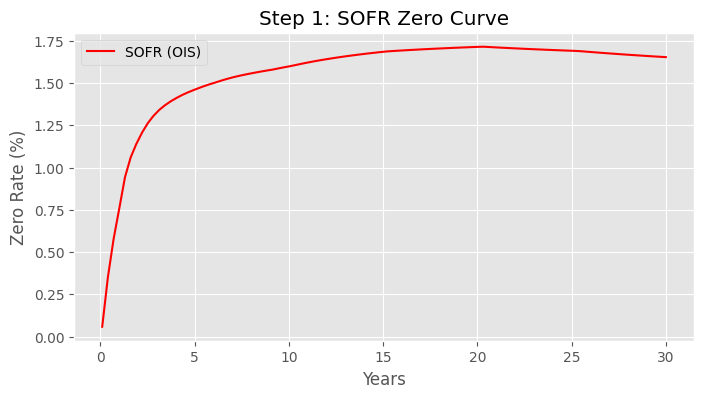

In [ ]:

sofrCurve = Curve("SOFR")
sofrPoints = []
for tenor, ratePct in sofrData:
    rate = ratePct / 100.0
    maturityDate = calendar.advance(spotDate, tenor, businessConvention)
    timeEnd = dayCount.yearFraction(spotDate, maturityDate)
    
    def solverFuncOis(x):
        dfEndGuess = x[0]
        sofrCurve.addPoint(timeEnd, dfEndGuess)
        
        # Расчет Fixed Leg
        paymentDates = generateSchedule(spotDate, tenor, freqMultiplier=1)
        fixedLegPv = 0.0
        prevDate = spotDate
        for date in paymentDates:
            t = dayCount.yearFraction(spotDate, date)
            tau = dayCount.yearFraction(prevDate, date)
            df = sofrCurve.getDiscountFactor(t)
            fixedLegPv += rate * tau * df
            prevDate = date
            
        # Расчет Float Leg
        # PV_float ≈ 1.0 - P_d(T_end) 
        # Плавающая нога OIS платит накопленную ставку.
        # (1 + R_total) = P(Start) / P(End).
        # Выплата (Payoff): P(Start)/P(End) - 1.
        # PV: Payoff * P(End) = P(Start) - P(End).
        # платежи сокращаются (P(t0)-P(t1)) + (P(t1)-P(t2))... 
        # Остается P(t_start) - P(t_end).
        # P(0) = 1.0.
        
        floatLegPv = 1.0 - sofrCurve.getDiscountFactor(timeEnd)
        
        sofrCurve.times.pop()
        sofrCurve.dfs.pop()
        
        # PV_float - PV_fixed = 0
        return floatLegPv - fixedLegPv

    initialGuess = np.exp(-rate * timeEnd)
    root = fsolve(solverFuncOis, [initialGuess])[0]
    sofrCurve.addPoint(timeEnd, root)
    sofrPoints.append(timeEnd) 


# SOFR 
times = np.linspace(0.1, 30, 100)
sofrRates = [sofrCurve.getZeroRate(t)*100 for t in times]

plt.figure(figsize=(8, 4))
plt.plot(times, sofrRates, label='SOFR (OIS)', color='red')
plt.title('Step 1: SOFR Zero Curve')
plt.xlabel('Years')
plt.ylabel('Zero Rate (%)')
plt.legend()
plt.grid(True)
plt.show() 


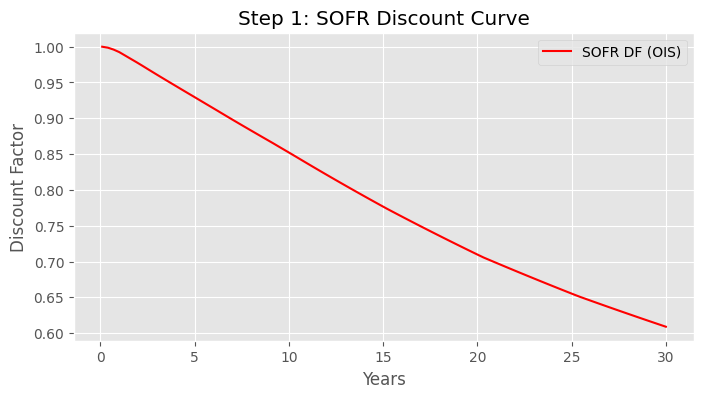

In [6]:
times = np.linspace(0.1, 30, 100)
dfsSofrStep1 = [sofrCurve.getDiscountFactor(t) for t in times]

plt.figure(figsize=(8, 4))
plt.plot(times, dfsSofrStep1, label='SOFR DF (OIS)', color='red')
plt.title('Step 1: SOFR Discount Curve') # Заголовок изменился
plt.xlabel('Years')
plt.ylabel('Discount Factor') # Ось Y изменилась
plt.legend()
plt.grid(True)
plt.show()

### Шаг 2: Построение кривой 3M LIBOR с использованием SOFR для дисконтирования

На втором шаге строим форвардную кривую $P_f^{3M}(t)$ для 3M LIBOR, используя SOFR как кривую дисконтирования.

**Депозит (3M):** Используем простое начисление процентов

$$
P_f^{3M}(0,T) = \frac{1}{1 + L(0,T) \cdot \tau}
$$

где $L(0,T)$ - ставка депозита, $\tau$ - длина периода в годах.

**FRA (Forward Rate Agreement):** Из условия нулевой стоимости FRA:

$$
P_d(0,T_{start}) - (1 + \tau K) \cdot P_f^{3M}(0,T_{end}) = 0
$$

откуда:

$$
P_f^{3M}(0,T_{end}) = \frac{P_d(0,T_{start})}{1 + \tau K}
$$

где $K$ - ставка FRA.

**IRS (Interest Rate Swap):** Уравнение калибровки для свопа с частотой купонов 3M против годовых фиксированных платежей:

$$
\sum_{j=1}^{m} P_d(0,T_j) \tau_j K = \sum_{i=1}^{n} P_d(0,T_i) \left[ \frac{P_f^{3M}(0,T_{i-1})}{P_f^{3M}(0,T_i)} - 1 \right]
$$

где левая часть - фиксированная нога, правая - плавающая (3M LIBOR).

>> Кривая 3M выше же кривой SOFR на спред


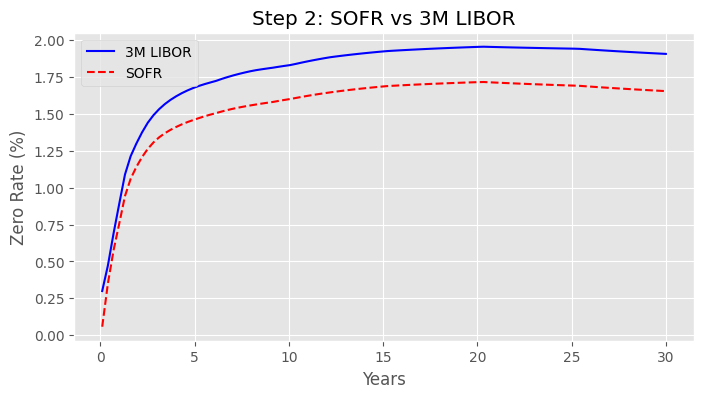

In [ ]:
# 3M LIBOR 
# Дисконтирование (PV) производится по уже построенной кривой SOFR (P_d) через IRS (Swap):
#    PV_fix = sum( K * dt * P_d(t) ) -- Дисконт по SOFR
#    PV_float = sum( L_fwd * dt * P_d(t) ) -- Дисконт по SOFR
#    L_fwd = ( P_f3m(t_start) / P_f3m(t_end) - 1 ) / dt

libor3mCurve = Curve("3M LIBOR")
libor3mPoints = []


# Deposit (3M)
tenorDepo, rateDepo = libor3mDepo[0]
maturityDepo = calendar.advance(spotDate, tenorDepo, businessConvention)
timeEndDepo = dayCount.yearFraction(spotDate, maturityDepo)
libor3mPoints.append(timeEndDepo)
tauDepo = dayCount.yearFraction(spotDate, maturityDepo)

# P_f3m(T) = 1 / (1 + r * t)
df3mEnd = 1.0 / (1.0 + (rateDepo/100.0) * tauDepo)
libor3mCurve.addPoint(timeEndDepo, df3mEnd)

# FRA
for startM, endM, ratePct in libor3mFra:
    rate = ratePct / 100.0
    startD = calendar.advance(spotDate, ql.Period(startM, ql.Months), businessConvention)
    endD = calendar.advance(spotDate, ql.Period(endM, ql.Months), businessConvention)
    timeStart = dayCount.yearFraction(spotDate, startD)
    timeEnd = dayCount.yearFraction(spotDate, endD)
    tau = dayCount.yearFraction(startD, endD)
    
    dfStart3m = libor3mCurve.getDiscountFactor(timeStart)
    # L = (Df_start/Df_end - 1)/tau => Df_end = Df_start / (1 + L*tau)
    dfEnd3m = dfStart3m / (1.0 + rate * tau)
    libor3mCurve.addPoint(timeEnd, dfEnd3m)
    libor3mPoints.append(timeEnd)

# IRS 
for tenor, ratePct in libor3mSwap:
    rate = ratePct / 100.0
    maturityDate = calendar.advance(spotDate, tenor, businessConvention)
    timeEnd = dayCount.yearFraction(spotDate, maturityDate)
    
    def solverFuncIrs(x):
        libor3mCurve.addPoint(timeEnd, x[0])
        
        fixedDates = generateSchedule(spotDate, tenor, freqMultiplier=1)
        fixedPv = 0.0
        prevD = spotDate
        for d in fixedDates:
            t = dayCount.yearFraction(spotDate, d)
            tau = dayCount.yearFraction(prevD, d)
            fixedPv += rate * tau * sofrCurve.getDiscountFactor(t)
            prevD = d
            
        floatDates = generateSchedule(spotDate, tenor, freqMultiplier=4)
        floatPv = 0.0
        prevD = spotDate
        for d in floatDates:
            t = dayCount.yearFraction(spotDate, d)
            tPrev = dayCount.yearFraction(spotDate, prevD)
            tau = dayCount.yearFraction(prevD, d)
            
            p3mStart = libor3mCurve.getDiscountFactor(tPrev)
            p3mEnd = libor3mCurve.getDiscountFactor(t)
            lFwd = (p3mStart / p3mEnd - 1.0) / tau
            
            dfSofr = sofrCurve.getDiscountFactor(t)
            floatPv += lFwd * tau * dfSofr
            prevD = d
            
        libor3mCurve.times.pop()
        libor3mCurve.dfs.pop()
        return floatPv - fixedPv

    initialGuess = np.exp(-rate * timeEnd)
    root = fsolve(solverFuncIrs, [initialGuess])[0]
    libor3mCurve.addPoint(timeEnd, root)
    libor3mPoints.append(timeEnd)

# print("Кривая 3M выше же кривой SOFR на спред")

# SOFR + 3M 
l3Rates = [libor3mCurve.getZeroRate(t)*100 for t in times]

plt.figure(figsize=(8, 4))
plt.plot(times, l3Rates, label='3M LIBOR', color='blue')
plt.plot(times, sofrRates, label='SOFR', color='red', linestyle='--')
plt.title('Step 2: SOFR vs 3M LIBOR')
plt.xlabel('Years')
plt.ylabel('Zero Rate (%)')
plt.legend()
plt.grid(True)
plt.show()


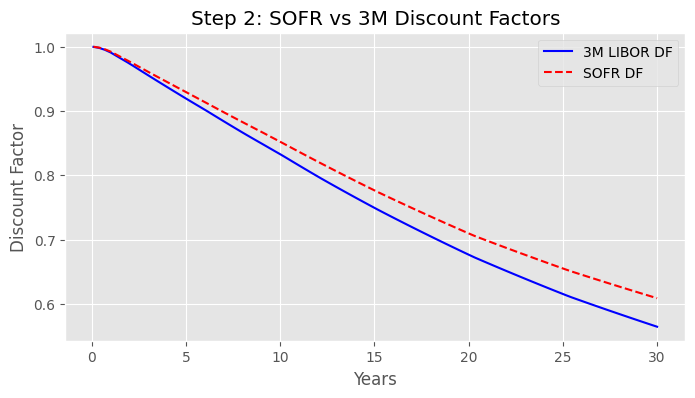

In [8]:
dfs3mStep2 = [libor3mCurve.getDiscountFactor(t) for t in times]
dfsSofrStep2 = [sofrCurve.getDiscountFactor(t) for t in times]

plt.figure(figsize=(8, 4))
plt.plot(times, dfs3mStep2, label='3M LIBOR DF', color='blue')
plt.plot(times, dfsSofrStep2, label='SOFR DF', color='red', linestyle='--')
plt.title('Step 2: SOFR vs 3M Discount Factors')
plt.xlabel('Years')
plt.ylabel('Discount Factor') 
plt.legend()
plt.grid(True)
plt.show()

### Шаг 3: Построение кривой 6M LIBOR через Basis Swaps

Basis Swap уравнивает приведенные стоимости двух плавающих ног:

$$
PV(3M\ LIBOR + Spread) = PV(6M\ LIBOR)
$$

где:

**Левая часть (3M + спред $s$):**

$$
PV_{3M} = \sum_{i=1}^{n} P_d(0, T_i^{3M}) \left[ \frac{P_f^{3M}(0, T_{i-1}^{3M})}{P_f^{3M}(0, T_i^{3M})} - 1 + s \cdot \tau_i^{3M} \right]
$$

**Правая часть (6M):**

$$
PV_{6M} = \sum_{j=1}^{m} P_d(0, T_j^{6M}) \left[ \frac{P_f^{6M}(0, T_{j-1}^{6M})}{P_f^{6M}(0, T_j^{6M})} - 1 \right]
$$

Уравнение калибровки: $PV_{3M} = PV_{6M}$

Здесь $P_f^{6M}$ - искомая кривая для 6M LIBOR, а $P_f^{3M}$ - уже построенная кривая 3M LIBOR.

Кривая 6M  выше 3M


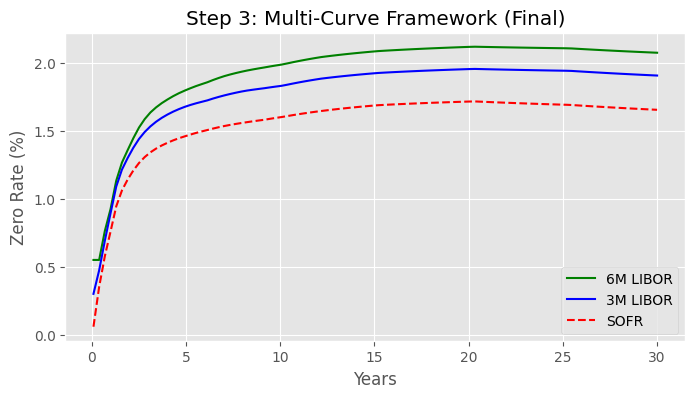

In [ ]:
# 6M LIBOR 
# Строим форвардную кривую P_f6m(t) через Basis Swap (3M + Spread vs 6M).
# Все денежные потоки дисконтируются по SOFR (P_d).
# Уравнение: PV(Leg_3M) = PV(Leg_6M)
#    - Leg_3M: (L_3m + Spread) * dt * P_d. L_3m берем из кривой 3M.
#    - Leg_6M: L_6m * dt * P_d. L_6m берем из искомой кривой 6M.

libor6mCurve = Curve("6M LIBOR")
libor6mPoints = []

# Deposit 6M
tenorDepo6, rateDepo6 = libor6mDepo[0]
maturityDepo6 = calendar.advance(spotDate, tenorDepo6, businessConvention)
timeEndDepo6 = dayCount.yearFraction(spotDate, maturityDepo6)
tauDepo6 = dayCount.yearFraction(spotDate, maturityDepo6)
df6mEnd = 1.0 / (1.0 + (rateDepo6/100.0) * tauDepo6)
libor6mCurve.addPoint(timeEndDepo6, df6mEnd)
libor6mPoints.append(timeEndDepo6)

# Basis Swaps
for tenor, spreadBps in libor6mBasis:
    spread = spreadBps / 10000.0
    maturityDate = calendar.advance(spotDate, tenor, businessConvention)
    timeEnd = dayCount.yearFraction(spotDate, maturityDate)
    
    def solverFuncBasis(x):
        libor6mCurve.addPoint(timeEnd, x[0])
        
        # Leg 1: 3M Libor + Spread
        dates3m = generateSchedule(spotDate, tenor, freqMultiplier=4)
        leg3mPv = 0.0
        prevD = spotDate
        for d in dates3m:
            t = dayCount.yearFraction(spotDate, d)
            tPrev = dayCount.yearFraction(spotDate, prevD)
            tau = dayCount.yearFraction(prevD, d)
            
            p3mStart = libor3mCurve.getDiscountFactor(tPrev)
            p3mEnd = libor3mCurve.getDiscountFactor(t)
            l3mFwd = (p3mStart / p3mEnd - 1.0) / tau
            dfSofr = sofrCurve.getDiscountFactor(t)
            
            leg3mPv += (l3mFwd + spread) * tau * dfSofr
            prevD = d
            
        # Leg 2: 6M Libor (Искомая)
        dates6m = generateSchedule(spotDate, tenor, freqMultiplier=2)
        leg6mPv = 0.0
        prevD = spotDate
        for d in dates6m:
            t = dayCount.yearFraction(spotDate, d)
            tPrev = dayCount.yearFraction(spotDate, prevD)
            tau = dayCount.yearFraction(prevD, d)
            
            p6mStart = libor6mCurve.getDiscountFactor(tPrev)
            p6mEnd = libor6mCurve.getDiscountFactor(t)
            l6mFwd = (p6mStart / p6mEnd - 1.0) / tau
            dfSofr = sofrCurve.getDiscountFactor(t)
            
            leg6mPv += l6mFwd * tau * dfSofr
            prevD = d
        
        libor6mCurve.times.pop()
        libor6mCurve.dfs.pop()
        return leg3mPv - leg6mPv

    initialGuess = np.exp(-0.02 * timeEnd)
    root = fsolve(solverFuncBasis, [initialGuess])[0]
    libor6mCurve.addPoint(timeEnd, root)
    libor6mPoints.append(timeEnd)

# print("Кривая 6M  выше 3M")

# SOFR + 3M + 6M 
l6Rates = [libor6mCurve.getZeroRate(t)*100 for t in times]

plt.figure(figsize=(8, 4))
plt.plot(times, l6Rates, label='6M LIBOR', color='green')
plt.plot(times, l3Rates, label='3M LIBOR', color='blue')
plt.plot(times, sofrRates, label='SOFR', color='red', linestyle='--')
plt.title('Step 3: Multi-Curve Framework (Final)')
plt.xlabel('Years')
plt.ylabel('Zero Rate (%)')
plt.legend()
plt.grid(True)
plt.show()




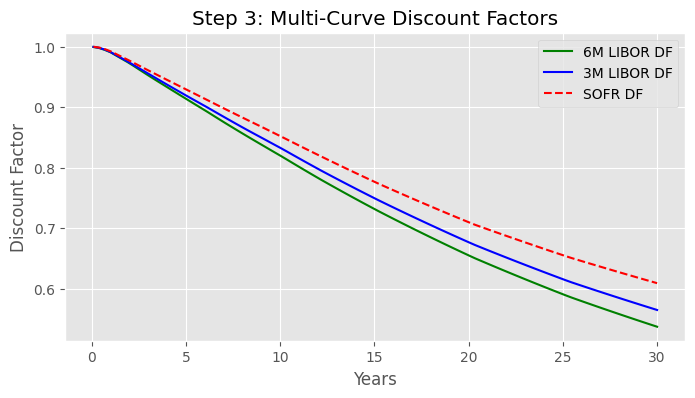

In [10]:
dfs6mStep3 = [libor6mCurve.getDiscountFactor(t) for t in times]
dfs3mStep3 = [libor3mCurve.getDiscountFactor(t) for t in times]
dfsSofrStep3 = [sofrCurve.getDiscountFactor(t) for t in times]

plt.figure(figsize=(8, 4))
plt.plot(times, dfs6mStep3, label='6M LIBOR DF', color='green')
plt.plot(times, dfs3mStep3, label='3M LIBOR DF', color='blue')
plt.plot(times, dfsSofrStep3, label='SOFR DF', color='red', linestyle='--')
plt.title('Step 3: Multi-Curve Discount Factors')
plt.xlabel('Years')
plt.ylabel('Discount Factor')
plt.legend()
plt.grid(True)
plt.show()


Time (Y)   | Tenor      | SOFR DF      | 3M Libor DF  | 6M Libor DF 
----------------------------------------------------------------------
0.0778     | 1M         | 0.99998      | 0.99977      | 0.99957     
0.1694     | 2M         | 0.99982      | 0.99949      | 0.99907     
0.2472     | 3M         | 0.99950      | 0.99926      | 0.99864     
0.3333     | -          | 0.99905      | 0.99861      | 0.99817     
0.4250     | -          | 0.99843      | 0.99793      | 0.99767     
0.5028     | 6M         | 0.99783      | 0.99735      | 0.99724     
0.5889     | -          | 0.99711      | 0.99640      | 0.99613     
0.6750     | -          | 0.99625      | 0.99546      | 0.99502     
0.7583     | 9M         | 0.99538      | 0.99455      | 0.99394     
0.8417     | -          | 0.99445      | 0.99338      | 0.99287     
0.9306     | -          | 0.99335      | 0.99213      | 0.99173     
1.0139     | 1Y         | 0.99230      | 0.99095      | 0.99065     
2.0278     | 2Y         | 0.976

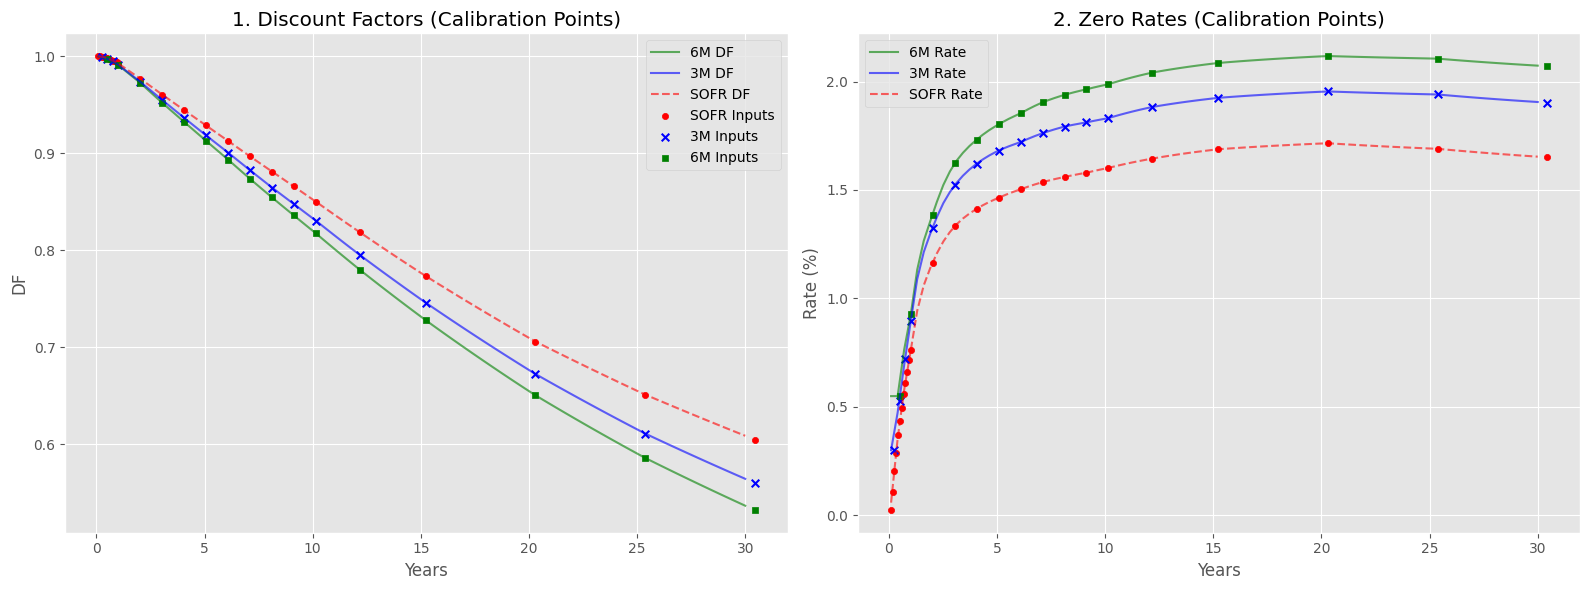

In [11]:
print("\n" + "="*70)
print(f"{'Time (Y)':<10} | {'Tenor':<10} | {'SOFR DF':<12} | {'3M Libor DF':<12} | {'6M Libor DF':<12}")
print("-" * 70)

allPoints = sorted(list(set(sofrPoints + libor3mPoints + libor6mPoints)))

for t in allPoints:
    tenorLabel = "-"
    if abs(t - 1.0/12) < 0.05: tenorLabel = "1M"
    elif abs(t - 2.0/12) < 0.05: tenorLabel = "2M"
    elif abs(t - 3.0/12) < 0.05: tenorLabel = "3M"
    elif abs(t - 6.0/12) < 0.05: tenorLabel = "6M"
    elif abs(t - 9.0/12) < 0.05: tenorLabel = "9M"
    elif abs(t - 1.0) < 0.05: tenorLabel = "1Y"
    elif abs(t - round(t)) < 0.05: tenorLabel = f"{int(round(t))}Y"
    
    dfS = sofrCurve.getDiscountFactor(t)
    df3 = libor3mCurve.getDiscountFactor(t)
    df6 = libor6mCurve.getDiscountFactor(t)
    
    print(f"{t:<10.4f} | {tenorLabel:<10} | {dfS:<12.5f} | {df3:<12.5f} | {df6:<12.5f}")

print("="*70)


times = np.linspace(0.1, 30, 100)
dfsSofr = [sofrCurve.getDiscountFactor(t) for t in times]
dfs3m = [libor3mCurve.getDiscountFactor(t) for t in times]
dfs6m = [libor6mCurve.getDiscountFactor(t) for t in times]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# DFs
ax1.plot(times, dfs6m, label='6M DF', color='green', alpha=0.6)
ax1.plot(times, dfs3m, label='3M DF', color='blue', alpha=0.6)
ax1.plot(times, dfsSofr, label='SOFR DF', color='red', linestyle='--', alpha=0.6)

# Точки
sofrScatter = [sofrCurve.getDiscountFactor(t) for t in sofrPoints]
l3Scatter = [libor3mCurve.getDiscountFactor(t) for t in libor3mPoints]
l6Scatter = [libor6mCurve.getDiscountFactor(t) for t in libor6mPoints]



ax1.scatter(sofrPoints, sofrScatter, color='red', marker='o', s=20, label='SOFR Inputs')
ax1.scatter(libor3mPoints, l3Scatter, color='blue', marker='x', s=30, label='3M Inputs')
ax1.scatter(libor6mPoints, l6Scatter, color='green', marker='s', s=20, label='6M Inputs')

ax1.set_title("1. Discount Factors (Calibration Points)")
ax1.set_xlabel("Years")
ax1.set_ylabel("DF")
ax1.legend()
ax1.grid(True)

# Rates
ratesSofr = [sofrCurve.getZeroRate(t)*100 for t in times]
rates3m = [libor3mCurve.getZeroRate(t)*100 for t in times]
rates6m = [libor6mCurve.getZeroRate(t)*100 for t in times]

ax2.plot(times, rates6m, label='6M Rate', color='green', alpha=0.6)
ax2.plot(times, rates3m, label='3M Rate', color='blue', alpha=0.6)
ax2.plot(times, ratesSofr, label='SOFR Rate', color='red', linestyle='--', alpha=0.6)

# Точки
sofrRatePoints = [sofrCurve.getZeroRate(t)*100 for t in sofrPoints]
l3RatePoints = [libor3mCurve.getZeroRate(t)*100 for t in libor3mPoints]
l6RatePoints = [libor6mCurve.getZeroRate(t)*100 for t in libor6mPoints]

ax2.scatter(sofrPoints, sofrRatePoints, color='red', marker='o', s=20)
ax2.scatter(libor3mPoints, l3RatePoints, color='blue', marker='x', s=30)
ax2.scatter(libor6mPoints, l6RatePoints, color='green', marker='s', s=20)

ax2.set_title("2. Zero Rates (Calibration Points)")
ax2.set_xlabel("Years")
ax2.set_ylabel("Rate (%)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()